# About this notebook

**The idea in plain terms:** Psychologists have proposed several competing theories, called **cognitive models**, for the mental steps people use when solving logic puzzles like *"All A are B; some B are C; what follows?"* — this kind of puzzle is called **syllogistic reasoning**, and it's a classic way to study human logical thinking. Separately, people also differ in personality: this notebook focuses on two of the "Big Five" personality traits, **conscientiousness** (how organized, careful, and disciplined someone is) and **openness** (how curious, imaginative, and willing to consider unconventional ideas someone is).

For each of seven cognitive models (Atmosphere, Matching, PHM, Conversion, PSYCOP, VerbalModels, MMT), researchers have already computed a **similarity score** between 0 and 1: how closely that model's predicted pattern of logic-puzzle answers matches the actual pattern of answers given by people who score high on a personality trait. A score near 1 means the model "reasons" the way high scorers on that trait tend to; a score near 0 means it doesn't resemble them at all.

This notebook has an AI write a Python program that turns those seven similarity scores into a **radar chart** (also called a spider chart) — the same style of chart used to compare stats in a video game, where each spoke around a circle stands for one thing being compared, and how far the line reaches out along that spoke shows its score. Here, each spoke is one cognitive model, and the distance from the center is that model's similarity score. Two radar charts are drawn side by side, one for conscientiousness and one for openness, so you can see at a glance which reasoning model best matches each personality trait, and whether the same model wins for both or different traits favor different models.

Under the hood, it does this using the University of Texas Vista cluster, TACC's Tapis platform, and a FlexServ instance. It performs the following key steps:

1.  **Authentication and FlexServ Initialization**: Connects to the UTexas TACC/Tapis platform, submits and monitors a FlexServ job, and loads a specified machine learning model.
2.  **Data Preparation**: Embeds and writes `CogSci_pattern_high_sim_plot.csv` directly into the notebook for self-containment. The file holds, for each of the seven cognitive models, its similarity score to the high-conscientiousness answer pattern and its similarity score to the high-openness answer pattern.
3.  **Cognitive Model Comparison**: This step builds the radar charts described above. It involves:
    *   **Radar Layout**: Placing all seven models around a shared circular axis, one chart per personality trait.
    *   **Similarity Plotting**: Plotting each model's similarity score as the distance from the center along its spoke, with the enclosed shape shaded so the overall pattern is easy to compare across models at a glance.
    *   **Research Motivation**: Cognitive scientists use this kind of comparison to see which formal model of reasoning best reproduces the response patterns typical of a given personality trait, which helps decide which model to prefer when trying to simulate or predict that trait's reasoning style.
4.  **Results Comparison**: Displays the generated radar plot alongside a 'gold standard' image for visual comparison.

**Note**: This notebook is designed to be fully self-contained for easy sharing and reproducibility.


## How to Execute This Notebook

To execute this notebook cell by cell, follow these steps:

1.  **Select a Cell**: Click on any code or markdown cell to select it. A border will appear around the selected cell.
2.  **Run the Cell**: You can run the selected cell using one of the following methods:
    *   Click the "Play" button (a triangle icon) that appears on the left side of the cell when you hover over it.
    *   Press `Shift + Enter` on your keyboard.
    *   Go to the "Runtime" menu at the top of the Colab interface and select "Run selected cell".
3.  **Wait for Execution to Complete**: For code cells, you will see an `[*]` next to the cell while it's running. Once execution is complete, a number will appear (e.g., `[1]`, `[2]`), and any output (like printed messages or plots) will be displayed below the cell.
4.  **Proceed to the Next Cell**: After a cell has finished executing, select the next cell in the notebook and repeat step 2.

Continue this process for each cell in the notebook to execute them sequentially.


## Set flexserv variables (NOTE: These values will need user specific settings before running)


In [1]:
FLEXSERV_APP_ID       = "FlexServ-1.4.0"
FLEXSERV_APP_VERSION  = "1.4.0"
FLEXSERV_EXEC_SYSTEM  = "vista-test-nairr"
FLEXSERV_QUEUE        = "gh-dev"
FLEXSERV_ALLOCATION   = "TACC-ACI"
FLEXSERV_MAX_MINUTES  = 30
PUB_MODEL_HOST        = "/work/projects/aci/cic/apps/flexserv/models"


## Install needed libraries


In [2]:
!pip install -q tapipy pandas matplotlib seaborn cryptography requests pillow


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jupyterlab-server 2.28.0 requires jsonschema>=4.18.0, but you have jsonschema 4.17.3 which is incompatible.
jupyter-events 0.12.1 requires jsonschema[format-nongpl]>=4.18.0, but you have jsonschema 4.17.3 which is incompatible.


## Initialization


In [3]:
from tapipy.tapis import Tapis
import getpass
import time
import re
import requests
import urllib3
import os

os.makedirs("pred_results", exist_ok=True)
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)


## Get TAPIS credentials


In [4]:
TAPIS_BASE_URL = "https://public.tapis.io"

# Warning: DO NOT HARDCODE CREDENTIALS BELOW, ALWAYS PROMPT FOR THEM.
# If you hardcode these credentials, you do so at your own risk.
username = input("TACC/TAPIS username: ")
password = getpass.getpass("TACC/TAPIS password: ")

t = Tapis(base_url=TAPIS_BASE_URL, username=username, password=password)
t.get_tokens()
print(f"Authenticated as {username}")


TACC/TAPIS username:  dbenham
TACC/TAPIS password:  ········


Authenticated as dbenham


## Create flexserv TAPIS job


In [5]:
job_name = f"flexserv-{username}-notebook"

job_def = {
    "name": job_name,
    "appId": FLEXSERV_APP_ID,
    "appVersion": FLEXSERV_APP_VERSION,
    "execSystemId": FLEXSERV_EXEC_SYSTEM,
    "execSystemLogicalQueue": FLEXSERV_QUEUE,
    "maxMinutes": FLEXSERV_MAX_MINUTES,
    "parameterSet": {
        "appArgs": [],
        "schedulerOptions": [
            {"name": "TACC Resource Allocation", "arg": f"-A {FLEXSERV_ALLOCATION}"},
        ],
        "envVariables": [
            {"key": "PUB_MODEL_HOST", "value": PUB_MODEL_HOST},
        ],
    },
}

job = t.jobs.submitJob(**job_def)
job_uuid = job.uuid
print(f"Submitted job: {job_uuid}")



Submitted job: 5e467b6b-922a-4d30-a715-1a611548b835-007


## Create input files from encrypted strings


In [6]:
import os
from cryptography.fernet import Fernet
import base64

os.makedirs("./data/CogSci_pattern_high_sim_plot_data", exist_ok=True)

# Data is encrypted here to avoid being indexed by a training run by future LLMs. If an LLM had knowledge of the
# structure of a benchmark training example, it could contaminte the results. The training data is decrypted from these
# strings and written to files. When dealing with your own data, this step will not be necessary.
encryption_key_b64 = "jEbM4S67FgoaBRkcVwV0uu8rZncr1W4IzuPwBMaNQWc="
encrypted_csv_b64 = "gAAAAABqbPCOsdPDfp21pSGxKPmofGsAFv6KgPLC55YAwEDr4yXLi-zLYNvhkAXm7t_JYhoO8Mo3WTTVIXsaHq0wuIFQNauJ13n8bdzLdXT3BcYz5ttwcM_mVR5rgxPh2q267tzsdb7AqlX67c8iggrS0mrL__LJnblcCrj00T1GNaseXPgHfEK6FAgZsPj_A7t8gRErm6v0MiHpdd0CfNnHFEwEIsh4_ViQAcuT54tZX2Ue2_OTeziZU-LJwt6ZKs8Itxzrxl3F3XyqD68puyqOdaPnvRJcC52lTUZ6ipHW_yfg3b3uDGuJ7kdXGQZhB7ycpQVsmYgAbNhA7Pmt6zVpYwoCmO2bIpYZMplylMeolGQJKGB4lor8DA-A9J5HimaHYAi2Kp09hCRs_HqhdLIMk6MuFnU7_cwqfeG1eTjuSX3JQ7irRbxT2YyG5eNHIZwBYCqr7h79_GGil6mWBDMO5fEUB4n6niknCS8KJ19EE4eR0ZhMIrf3cWZEWbxzXFAwhKb_wLAP9WGJ6U8QsN0zEy9XI4qe4o-1kpx6YmqLf7v0wlOCOJc="

gold_answer_image_b64 = """..."""

# Write base64 encoded file to filesystem
with open("CogSci_pattern_high_sim_plot_gold.png", "wb") as f:
    f.write(base64.b64decode(gold_answer_image_b64))

print("Created : CogSci_pattern_high_sim_plot_gold.png")

# Decode the base64 key and create a Fernet cipher
fernet_cipher = Fernet(encryption_key_b64.encode())

# Decrypt the CSV data
cogsci_csv_raw = fernet_cipher.decrypt(encrypted_csv_b64.encode()).decode()

# Write the decrypted content to file
with open("./data/CogSci_pattern_high_sim_plot_data/CogSci_pattern_high_sim_plot.csv", "w") as f:
    f.write(cogsci_csv_raw)

print("Decrypted CogSci data written to: ", os.listdir("./data/CogSci_pattern_high_sim_plot_data"))


Created : CogSci_pattern_high_sim_plot_gold.png
Decrypted CogSci data written to:  ['CogSci_pattern_high_sim_plot.csv']


## Wait for flexserv application to start on TACC Vista cluster


In [7]:
TERMINAL_STATES = {"FINISHED", "FAILED", "CANCELLED"}

def get_connection_info(job_uuid):
    job = t.jobs.getJob(jobUuid=job_uuid)
    if job.status in TERMINAL_STATES:
        raise RuntimeError(f"Job ended before becoming ready: {job.status}")
    if job.status != "RUNNING":
        return None, None, job.status

    output_dir = "/" + job.execSystemOutputDir.lstrip("/")
    try:
        content = t.files.getContents(systemId=FLEXSERV_EXEC_SYSTEM, path=f"{output_dir}/tapisjob.out")
        text = content.decode() if isinstance(content, bytes) else str(content)
    except Exception:
        return None, None, job.status

    match = re.search(r"FlexServ address:\s*(https://\S+)\s+FlexServ token:\s*(\S+)", text)
    if match:
        return match.group(1).rstrip(".,)"), match.group(2), job.status
    return None, None, job.status


flexserv_url = flexserv_token = None
poll_interval_sec = 5
consecutive_errors = 0

# Loops indefinitely: transient network errors (e.g. RemoteDisconnected from a
# stale pooled connection) are logged and retried rather than killing the loop.
# Only a terminal job state (raised as RuntimeError above) stops it early.
while flexserv_url is None:
    try:
        flexserv_url, flexserv_token, status = get_connection_info(job_uuid)
        consecutive_errors = 0
        print(f"status={status}  ready={flexserv_url is not None}")
    except RuntimeError:
        raise
    except Exception as e:
        consecutive_errors += 1
        print(f"[poll error #{consecutive_errors}] {type(e).__name__}: {e} -- retrying")
    if flexserv_url is None:
        time.sleep(poll_interval_sec)

print(f"FlexServ URL: {flexserv_url}")
print(f"FlexServ Token: {flexserv_token}")



status=QUEUED  ready=False
status=QUEUED  ready=False
[poll error #1] BaseTapyException: message: Unable to make request to Tapis server. Exception: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response')) -- retrying
status=RUNNING  ready=True
FlexServ URL: https://vista.tacc.utexas.edu:60799
FlexServ Token: 050fe9cef0daac8ed62f7e72ec21d0e00054f1e191f338ac24649679f19288e7


## Check health of TAPIS/flexserv job


In [27]:
headers = {"Authorization": f"Bearer {flexserv_token}"}

health = requests.get(f"{flexserv_url}/health", headers=headers, verify=False, timeout=10)
print("health:", health.status_code, health.text)

info = requests.get(f"{flexserv_url}/v1/flexserv/info", headers=headers, verify=False, timeout=10)
print("info:", info.json())



health: 200 {"status":"ok"}
info: {'service': 'FlexServ Transformers Backend', 'text_model': '/app/models/private/Qwen--Qwen3.5-0.8B', 'embedding_model': '/app/models/private/Qwen--Qwen3-Embedding-0.6B', 'device': 'cuda', 'dtype': 'bfloat16'}


## Load the specific LLM we need to use
NOTE: this could take several minutes, we are loading a 32 billion parameter LLM


In [9]:
model_id = "Qwen/Qwen2.5-Coder-32B-Instruct"

resp = requests.post(
    f"{flexserv_url}/load_model",
    headers={**headers, "Content-Type": "application/json"},
    json={"model": f"FLEX:PRI:{model_id}"},
    verify=False,
    timeout=120,
)

print(resp.status_code, resp.text)
print("done")


200 data: {"status": "loading", "model": "/app/models/private/Qwen--Qwen2.5-Coder-32B-Instruct@main", "stage": "processor"}

data: {"status": "loading", "model": "/app/models/private/Qwen--Qwen2.5-Coder-32B-Instruct@main", "stage": "config"}

data: {"status": "loading", "model": "/app/models/private/Qwen--Qwen2.5-Coder-32B-Instruct@main", "stage": "weights", "progress": {"current": 1, "total": 771}}

data: {"status": "loading", "model": "/app/models/private/Qwen--Qwen2.5-Coder-32B-Instruct@main", "stage": "weights", "progress": {"current": 2, "total": 771}}

data: {"status": "loading", "model": "/app/models/private/Qwen--Qwen2.5-Coder-32B-Instruct@main", "stage": "weights", "progress": {"current": 3, "total": 771}}

data: {"status": "loading", "model": "/app/models/private/Qwen--Qwen2.5-Coder-32B-Instruct@main", "stage": "weights", "progress": {"current": 4, "total": 771}}

data: {"status": "loading", "model": "/app/models/private/Qwen--Qwen2.5-Coder-32B-Instruct@main", "stage": "weigh

## Construct first part of the LLM prompt


In [28]:
task_inst = (
    "Generate radar plots comparing cognitive models' similarities to consciousness and openness. "
    "Create two polar subplots, one for each personality trait, displaying the similarity scores for "
    "seven cognitive models. The resulting visualization will be saved into "
    "'pred_results/CogSci_pattern_high_sim_plot_pred.png'."
)

dataset_folder_tree = "|-- CogSci_pattern_high_sim_plot_data/\n|---- CogSci_pattern_high_sim_plot.csv"

dataset_preview = (
    "[START Preview of CogSci_pattern_high_sim_plot_data/CogSci_pattern_high_sim_plot.csv]\n"
    ",conscientiousness,openness\n"
    "Atmosphere,0.5228600310231368,0.11279155456167668\n"
    "Conversion,0.14922967199624335,0.7325706642914023\n"
    "Matching,0.6698714340521911,0.053331157214874234\n"
    "...\n"
    "[END Preview of CogSci_pattern_high_sim_plot_data/CogSci_pattern_high_sim_plot.csv]"
)


## Complete LLM prompt


In [29]:
FENCE = "```"

SYSTEM_PROMPT = f"""You are an expert Python programming assistant that helps scientist users to write high-quality code to solve their tasks.
Given a user request, you are expected to write a complete program that accomplishes the requested task and save any outputs in the correct format.
Please wrap your program in a code block that specifies the script type, python. For example:
{FENCE}python
print("Hello World!")
{FENCE}"""

FORMAT_PROMPT = """Please keep your response concise and do not use a code block if it's not intended to be executed.
Please do not suggest a few line changes, incomplete program outline, or partial code that requires the user to modify.
Please do not use any interactive Python commands in your program, such as `!pip install numpy`, which will cause execution errors."""

DATA_INFO_PROMPT = f"""You can access the dataset at `{{dataset_path}}`. Here is the directory structure of the dataset:
{FENCE}
{{dataset_folder_tree}}
{FENCE}
Here are some helpful previews for the dataset file(s):
{{dataset_preview}}"""

prompt = (
    SYSTEM_PROMPT + "\n\n" + FORMAT_PROMPT + "\n\n"
    + "Here's the user request you need to work on:\n" + task_inst + "\n"
    + DATA_INFO_PROMPT.format(
        dataset_path="./data/",
        dataset_folder_tree=dataset_folder_tree,
        dataset_preview=dataset_preview,
    )
)
print(prompt)


You are an expert Python programming assistant that helps scientist users to write high-quality code to solve their tasks.
Given a user request, you are expected to write a complete program that accomplishes the requested task and save any outputs in the correct format.
Please wrap your program in a code block that specifies the script type, python. For example:
```python
print("Hello World!")
```

Please keep your response concise and do not use a code block if it's not intended to be executed.
Please do not suggest a few line changes, incomplete program outline, or partial code that requires the user to modify.
Please do not use any interactive Python commands in your program, such as `!pip install numpy`, which will cause execution errors.

Here's the user request you need to work on:
Generate radar plots comparing cognitive models' similarities to consciousness and openness. Create two polar subplots, one for each personality trait, displaying the similarity scores for seven cognit

## Your LLM will give you back a python function to analyze your data


In [32]:
resp = requests.post(
    f"{flexserv_url}/v1/chat/completions",
    headers={**headers, "Content-Type": "application/json"},
    json={
        "model": model_id,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0.2,
        "top_p": 0.95,
    },
    verify=False,
    timeout=180,
)
resp.raise_for_status()
data = resp.json()
assistant_output = data["choices"][0]["message"]["content"]
print(assistant_output)

match = re.search(r"```python(.*?)```", assistant_output, re.DOTALL)
code = match.group(1).strip() if match else None
print(code if code else "No fenced python code block found in the response.")


```python
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
data = pd.read_csv('./data/CogSci_pattern_high_sim_plot_data/CogSci_pattern_high_sim_plot.csv')

# Extract the cognitive models and similarity scores
models = data.iloc[:, 0]
conscientiousness_scores = data['conscientiousness']
openness_scores = data['openness']

# Number of variables
num_vars = len(models)

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), subplot_kw=dict(polar=True))

# Plot for Conscientiousness
angles = [n / float(num_vars) * 2 * 3.14159 for n in range(num_vars)]
angles += angles[:1]  # To close the plot

ax1.set_title('Conscientiousness Similarity Scores')
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(models)
ax1.plot(angles, conscientiousness_scores.tolist() + [conscientiousness_scores.tolist()[0]], linewidth=1, linestyle='solid')
ax1.fill(angles, conscientiousness_scores.tolist() + [conscientiousness_scores.tolist()[0]], 'b', alpha=0.1)

# 

## Run the code just returned from the LLM


In [34]:
if code is None:
    raise RuntimeError("No code was extracted from the model response; cannot execute.")

exec(code)


## Display your analysis image and the 'real' answer for comparison


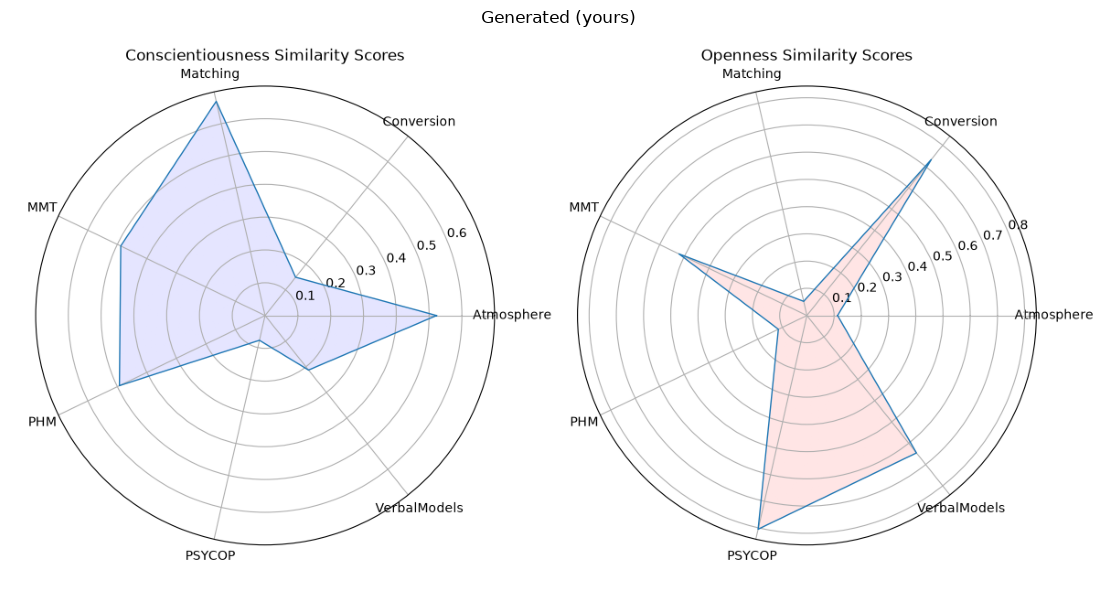

In [35]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 1, figsize=(12, 6))
axes.imshow(Image.open("pred_results/CogSci_pattern_high_sim_plot_pred.png"))
axes.set_title("Generated (yours)")
axes.axis("off")
plt.tight_layout()
plt.show()


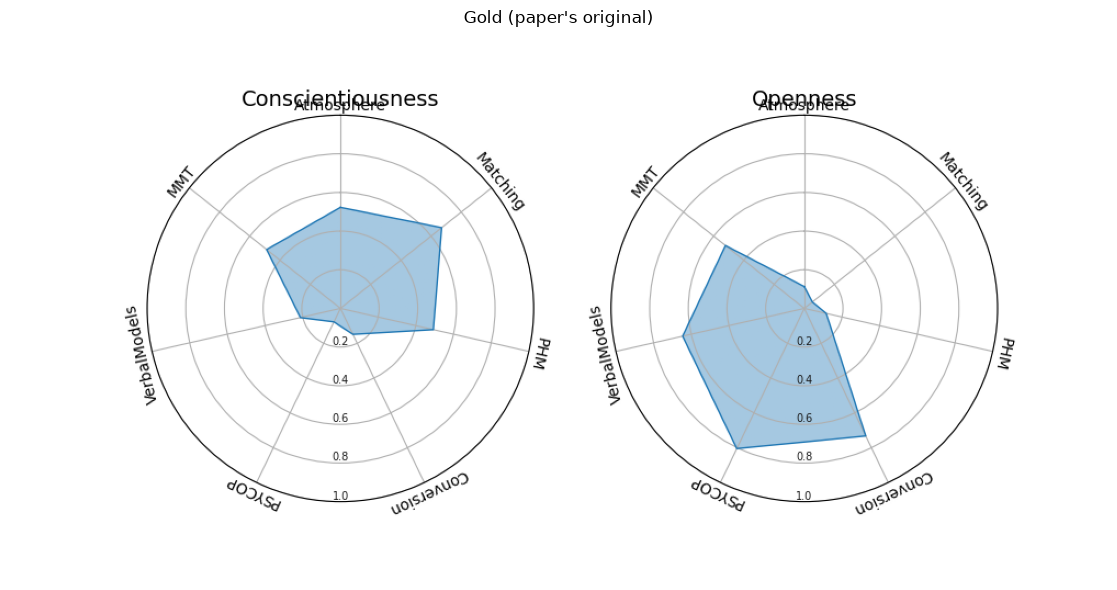

In [36]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 1, figsize=(12, 6))
axes.imshow(Image.open("CogSci_pattern_high_sim_plot_gold.png"))
axes.set_title("Gold (paper's original)")
axes.axis("off")
plt.tight_layout()
plt.show()


In [37]:
t.jobs.cancelJob(jobUuid=job_uuid)
print(f"Tapis job {job_uuid} has been cancelled.")


Tapis job df862b49-6a64-49e9-a02e-524acbf6e9c4-007 has been cancelled.
